In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
data = pd.read_csv("Developer_data.csv")
print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [4]:
print(data.head())

   Hours_Coding  Lines_of_Code  Bugs_Found  Bugs_Fixed  AI_Usage_Hours  \
0             7            416           9           7               6   
1             4            269          16          13               5   
2            11            439           3           0               2   
3             8            472          15           9               4   
4             5            265          19          16               5   

   Sleep_Hours  Cognitive_Load  Task_Success_Rate  Coffee_Intake  \
0          5.9              92                 34              7   
1          5.1              85                 36              2   
2          6.2              38                 79              2   
3          4.2              26                 94              5   
4          8.1              82                 33              6   

   Stress_Level  Task_Duration_Hours  Commits  Errors  
0            99                 10.5       20       3  
1           100                  9

In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours_Coding         1000 non-null   int64  
 1   Lines_of_Code        1000 non-null   int64  
 2   Bugs_Found           1000 non-null   int64  
 3   Bugs_Fixed           1000 non-null   int64  
 4   AI_Usage_Hours       1000 non-null   int64  
 5   Sleep_Hours          1000 non-null   float64
 6   Cognitive_Load       1000 non-null   int64  
 7   Task_Success_Rate    1000 non-null   int64  
 8   Coffee_Intake        1000 non-null   int64  
 9   Stress_Level         1000 non-null   int64  
 10  Task_Duration_Hours  1000 non-null   float64
 11  Commits              1000 non-null   int64  
 12  Errors               1000 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 101.7 KB
None


In [6]:
print(data.describe())

       Hours_Coding  Lines_of_Code   Bugs_Found   Bugs_Fixed  AI_Usage_Hours  \
count    1000.00000     1000.00000  1000.000000  1000.000000     1000.000000   
mean        5.84000      356.23400     9.876000     7.153000        2.961000   
std         3.15854      188.15535     5.796052     5.468226        2.021278   
min         1.00000       26.00000     0.000000     0.000000        0.000000   
25%         3.00000      209.50000     5.000000     2.000000        1.000000   
50%         6.00000      332.00000    10.000000     7.000000        3.000000   
75%         9.00000      480.50000    15.000000    12.000000        5.000000   
max        11.00000      993.00000    19.000000    19.000000        6.000000   

       Sleep_Hours  Cognitive_Load  Task_Success_Rate  Coffee_Intake  \
count  1000.000000     1000.000000        1000.000000    1000.000000   
mean      6.465800       56.933000          56.578000       3.368000   
std       1.439529       21.767506          20.814879       2.3

In [7]:
print("Dataset Shape:", data.shape)

Dataset Shape: (1000, 13)


In [8]:
print("\nMissing Values:\n", data.isnull().sum())


Missing Values:
 Hours_Coding           0
Lines_of_Code          0
Bugs_Found             0
Bugs_Fixed             0
AI_Usage_Hours         0
Sleep_Hours            0
Cognitive_Load         0
Task_Success_Rate      0
Coffee_Intake          0
Stress_Level           0
Task_Duration_Hours    0
Commits                0
Errors                 0
dtype: int64


# EDA

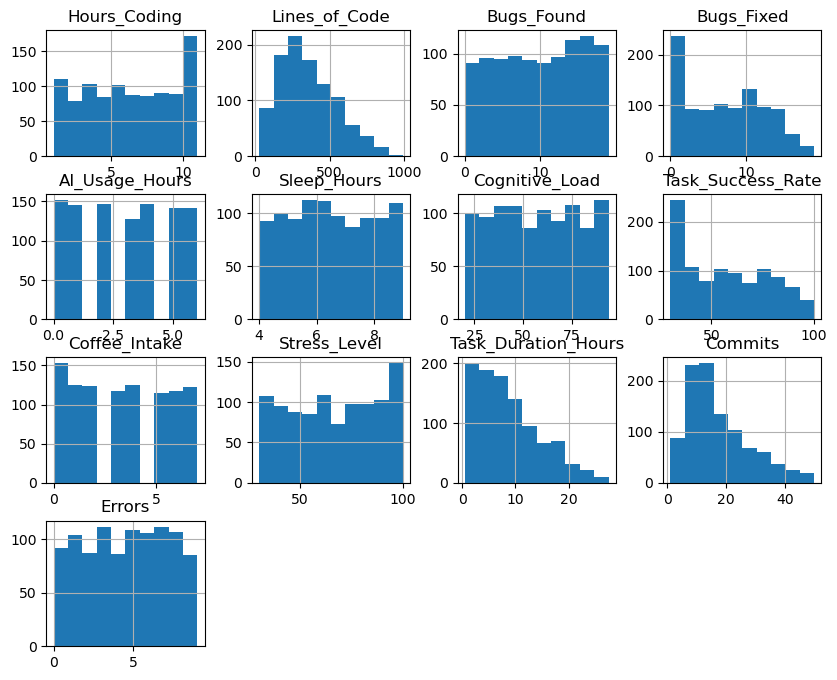

In [9]:
data.hist(figsize=(10,8))
plt.show()

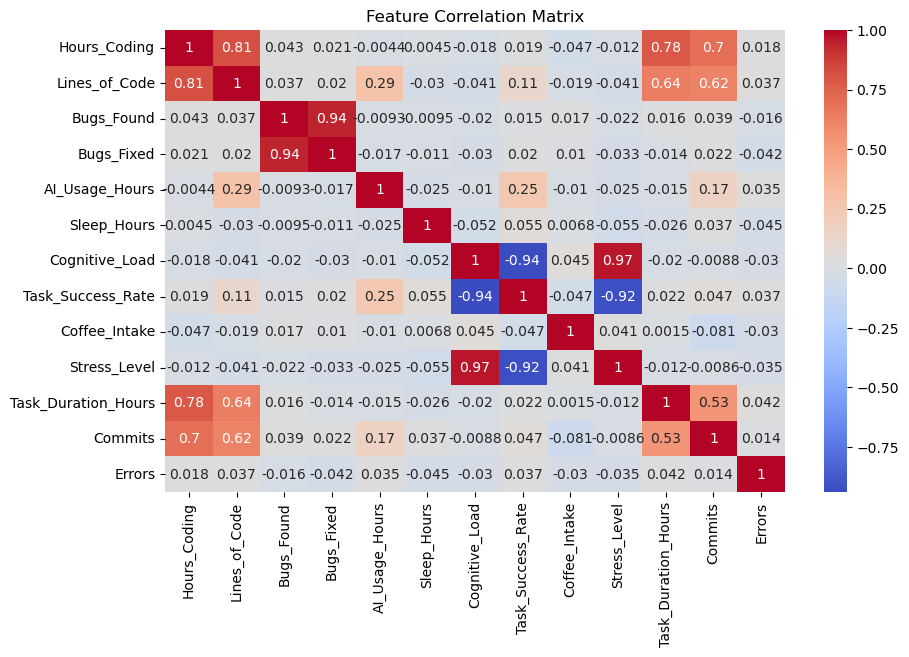

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

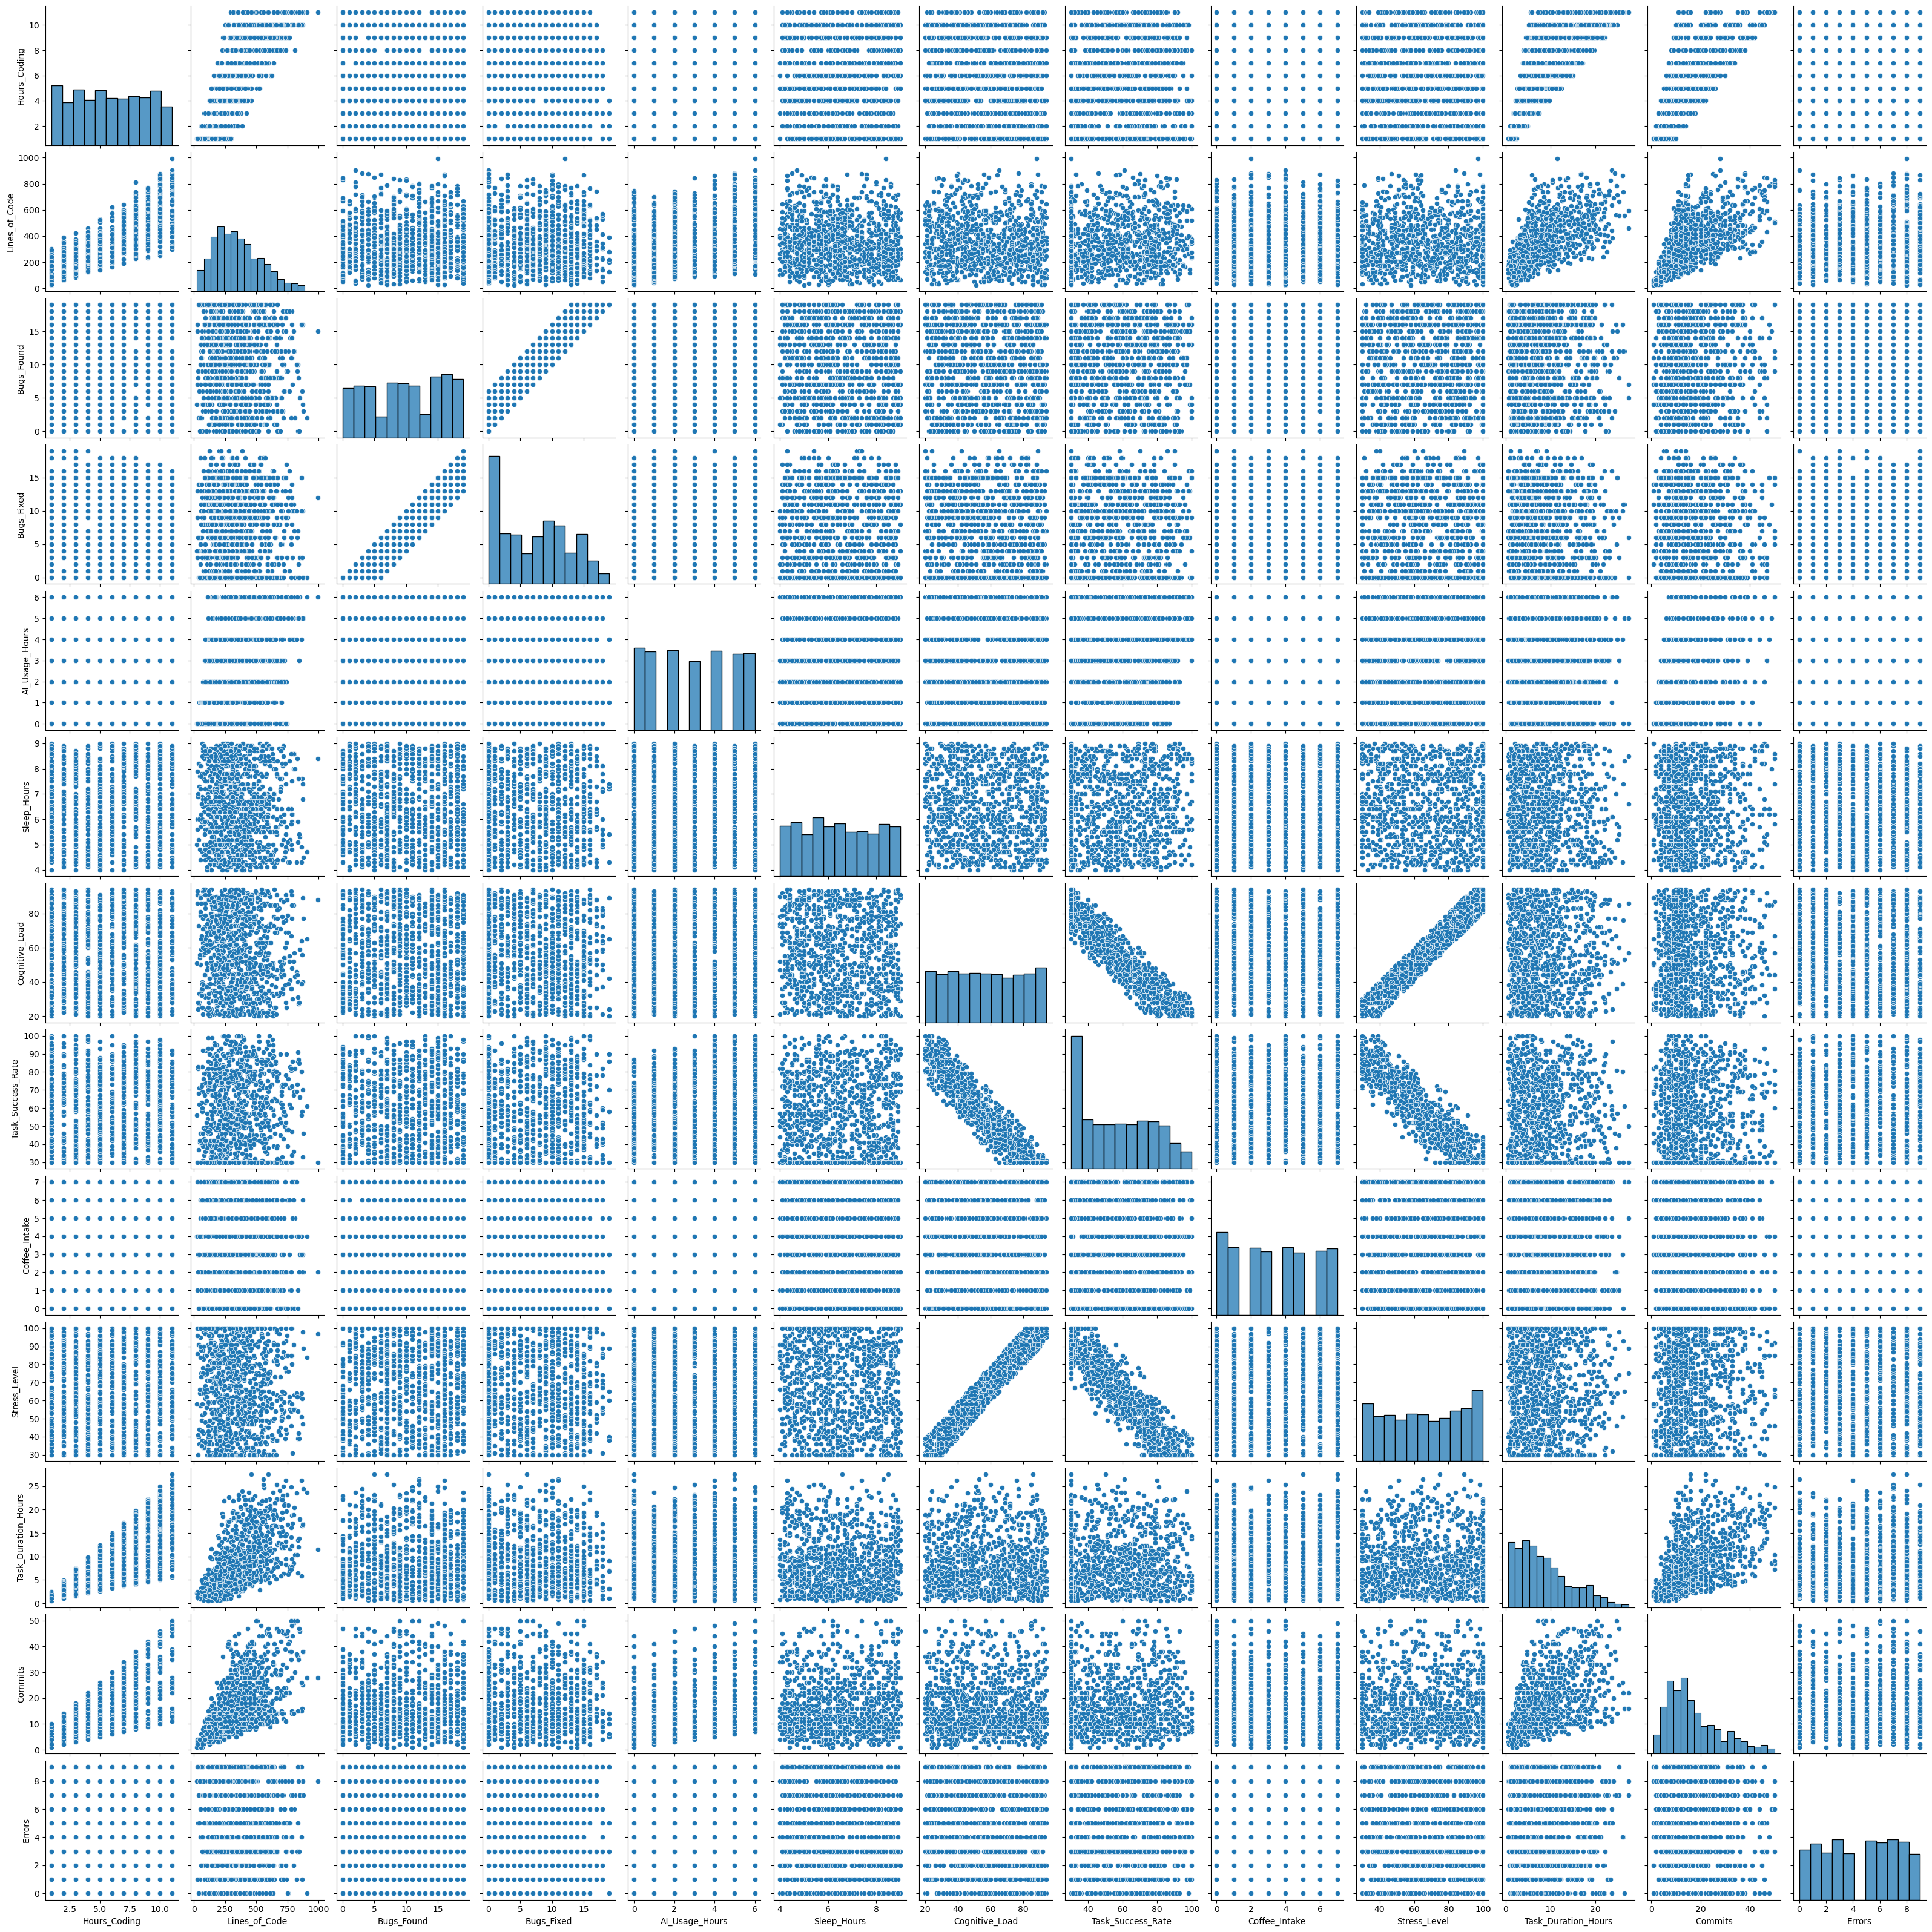

In [11]:
sns.pairplot(data)
plt.show()

In [13]:
Performance = Task_Success_Rate >= 60

NameError: name 'Task_Success_Rate' is not defined

In [14]:
def performance_label(x):
    if x < 50:
        return 0   # Low
    elif x < 75:
        return 1   # Medium
    else:
        return 2   # High

data["Performance"] = data["Task_Success_Rate"].apply(performance_label)

print(data["Performance"].value_counts())

Performance
0    418
1    336
2    246
Name: count, dtype: int64


In [15]:
X = data.drop(["Performance"], axis=1)
y = data["Performance"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# High Performance = 1, Low Performance = 0
data["Performance"] = (data["Task_Success_Rate"] >= 60).astype(int)

print("\n✅ Target column created: Performance")


✅ Target column created: Performance


In [19]:
X = data.drop(["Performance", "Task_Success_Rate"], axis=1)
y = data["Performance"]

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [23]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (800, 12)
Testing Data Shape: (200, 12)


In [24]:
# Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)
# Predict
y_pred_lr = model.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.92


## Decision Tree Model

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.92


## Random Forest Model

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.935


## Support Vector Machine (SVM)

In [20]:
from sklearn.svm import SVC

# Create model
svm_model = SVC(kernel='rbf', probability=True)

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.92


## K-Nearest Neighbors (KNN)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

# Create model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

# Accuracy
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.88


## Gradient Boosting

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

# Create model
gb_model = GradientBoostingClassifier()

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Accuracy
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.92


## Model Comparison

In [23]:
print("\nModel Comparison")

print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Gradient Boosting:", accuracy_score(y_test, y_pred_gb))


Model Comparison
Logistic Regression: 0.92
Decision Tree: 0.92
Random Forest: 0.935
SVM: 0.92
KNN: 0.88
Gradient Boosting: 0.92


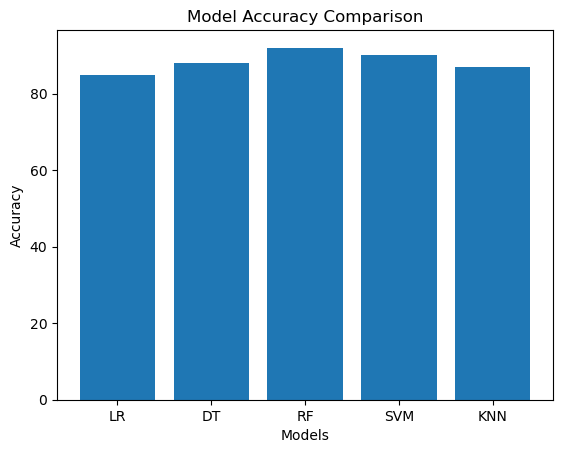

In [28]:
import matplotlib.pyplot as plt

models = ["LR","DT","RF","SVM","KNN"]
accuracy = [85,88,92,90,87]

plt.bar(models,accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [17]:
# ==============================
# 9️⃣ Evaluate Model
# ==============================

y_pred = model.predict(X_test)

print("\nModel Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.92

Confusion Matrix:
[[108   9]
 [  7  76]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       117
           1       0.89      0.92      0.90        83

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



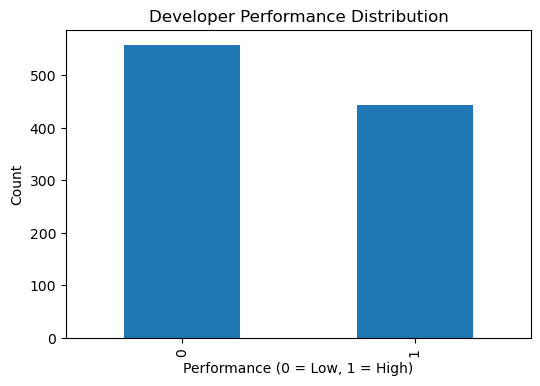

In [19]:
# ==============================
# 🔟 Visualize Performance
# ==============================

performance_counts = y.value_counts()

plt.figure(figsize=(6,4))
performance_counts.plot(kind='bar')
plt.xlabel("Performance (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.title("Developer Performance Distribution")
plt.show()

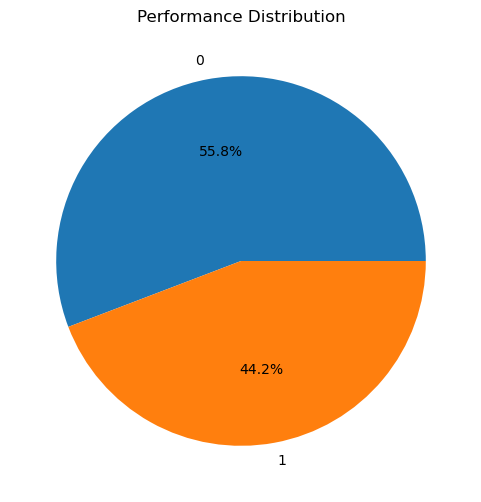

In [20]:
plt.figure(figsize=(6,6))
performance_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Performance Distribution")
plt.ylabel("")
plt.show()


In [27]:
# ==============================
# 1️⃣1️⃣ User Input Prediction
# ==============================

print("\nEnter values to predict developer performance:")

user_input = []

for col in X.columns:
    value = float(input(f"Enter {col}: "))
    user_input.append(value)

# Convert & Scale
user_input = np.array(user_input).reshape(1, -1)
user_input_scaled = scaler.transform(user_input)

# Predict
probability = model.predict_proba(user_input_scaled)[0]
prediction = model.predict(user_input_scaled)[0]

print("\nPrediction Result:")
print("Low Performance Probability:", round(probability[0]*100,2), "%")
print("High Performance Probability:", round(probability[1]*100,2), "%")

if prediction == 1:
    print("🚀 Predicted Performance: HIGH")
else:
    print("🔴 Predicted Performance: LOW")


Enter values to predict developer performance:


Enter Hours_Coding:  6
Enter Lines_of_Code:  300
Enter Bugs_Found:  77
Enter Bugs_Fixed:  22
Enter AI_Usage_Hours:  3
Enter Sleep_Hours:  2
Enter Cognitive_Load:  6
Enter Coffee_Intake:  7
Enter Stress_Level:  88
Enter Task_Duration_Hours:  60
Enter Commits:  6
Enter Errors:  44



Prediction Result:
Low Performance Probability: 1.94 %
High Performance Probability: 98.06 %
🚀 Predicted Performance: HIGH


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
